## Phase-1 Data Understanding and Preperation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

In [8]:
# Loading data and basic profiling

test = pd.read_csv('../data/test_data.csv')
train= pd.read_csv('../data/train_data.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')


Train shape : (8586, 16)
Test shape  : (8585, 15)


In [9]:
train.head(5)

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [10]:
test.head(5)

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Moreland,Australia,-37.766505,144.980736,Private room,2,1.0,1.0,1.0,3,108,87.0,t,1
1,t,Port Phillip,Australia,-37.859755,144.977369,Entire home/apt,3,1.0,1.0,2.0,3,15,94.0,f,17
2,f,Port Phillip,Australia,-37.864530,144.992238,Private room,2,1.0,1.0,2.0,1,63,90.0,f,1
3,f,Darebin,Australia,-37.697294,145.000816,Private room,2,1.0,1.0,1.0,7,159,94.0,f,3
4,f,Melbourne,Australia,-37.810267,144.985920,Private room,2,1.0,1.0,1.0,1,3,93.0,f,1


In [11]:
# Let's check the missing values first
train.isnull().sum()

host_is_superhost                 0
city                              0
country                           0
latitude                          0
longitude                         0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
price                             0
minimum_nights                    0
number_of_reviews                 0
review_scores_rating              0
instant_bookable                  0
calculated_host_listings_count    0
dtype: int64

In [ ]:
train.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])
# Worked on my own but took help of calude to work on my intution (for visualisation part)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host_is_superhost,8586,2,f,6105,nan,nan,nan,nan,nan,nan,nan
city,8586,30,Melbourne,2917,nan,nan,nan,nan,nan,nan,nan
country,8586,1,Australia,8586,nan,nan,nan,nan,nan,nan,nan
latitude,8586.000000,nan,nan,nan,-37.825074,0.065145,-38.224427,-37.849202,-37.816460,-37.802849,-37.491059
longitude,8586.000000,nan,nan,nan,145.009374,0.130473,144.531993,144.957065,144.977004,145.008316,145.760250
room_type,8586,3,Entire home/apt,5771,nan,nan,nan,nan,nan,nan,nan
accommodates,8586.000000,nan,nan,nan,3.559865,2.225801,1.000000,2.000000,3.000000,4.000000,16.000000
bathrooms,8586.000000,nan,nan,nan,1.282320,0.557906,0.000000,1.000000,1.000000,1.500000,9.000000
bedrooms,8586.000000,nan,nan,nan,1.533077,0.916369,0.000000,1.000000,1.000000,2.000000,10.000000
beds,8586.000000,nan,nan,nan,2.036222,1.544967,0.000000,1.000000,2.000000,2.000000,18.000000


In [20]:
# Let's check the data types in the train dataset
train.dtypes.to_frame(name='dtype')

,dtype
host_is_superhost,object
city,object
country,object
latitude,float64
longitude,float64
room_type,object
accommodates,int64
bathrooms,float64
bedrooms,float64
beds,float64


In [ ]:
# let's do variance filter and check if a particular feature has zero variance or not 
# Drop features with zero variance 
cols_to_drop = [col for col in train.columns if train[col].nunique() <= 1]

train.drop(columns=cols_to_drop,inplace=True)
test.drop(columns=cols_to_drop,inplace=True)

In [23]:
print(f'Column with zero variance dropped : {cols_to_drop}')

Column with zero variance dropped : ['country']


In [ ]:
train.shape,test.shape
# So we dropped one column which had zero variance

((8586, 15), (8585, 14))

In [38]:
# Let's do some univariate analysis and also check number of numerical and categorical features in the dataset

num_cols=train.select_dtypes(include=np.number).columns.tolist()
# first extracts the dataframe with only numerical columns and the extracts the columns name and the converts it into a list

cat_cols=train.select_dtypes(include='object').columns.tolist()

print(f'NUmerical columns ({len(num_cols)}) : {num_cols}')
print(f'Categorical columns ({len(cat_cols)}) : {cat_cols}')


NUmerical columns (11) : ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']
Categorical columns (4) : ['host_is_superhost', 'city', 'room_type', 'instant_bookable']


### Outlier detection and Univariate Analysis 

In [39]:
#
#skew_and_kurt =pd.DataFrame({
#    'skewness':train[num_cols].skew(),
#    'kurtosis':train[num_cols].kurtosis()
#}).round(3)

skew_and_kurt=pd.DataFrame(
  {
    'skewness':train[num_cols].skew(),
    'kurtosis':train[num_cols].kurtosis()
  }
).round(2)

In [40]:
skew_and_kurt

,skewness,kurtosis
latitude,-1.04,7.09
longitude,2.12,7.67
accommodates,1.81,5.02
bathrooms,2.76,14.41
bedrooms,1.60,4.67
beds,2.72,11.98
price,5.77,70.75
minimum_nights,38.83,1706.00
number_of_reviews,3.09,13.59
review_scores_rating,-3.88,23.72


In [41]:
# Lets add some bakground style to the skewness and kurtosis dataframe to visualise the values better
skew_and_kurt['skew_severity'] = skew_and_kurt['skewness'].abs().apply(lambda x:'Good' if x<1 else 'High')
skew_and_kurt['kurt_severity'] = skew_and_kurt['kurtosis'].abs().apply(lambda x:'Good' if x<3 else 'High')

In [42]:
skew_and_kurt

,skewness,kurtosis,skew_severity,kurt_severity
latitude,-1.04,7.09,High,High
longitude,2.12,7.67,High,High
accommodates,1.81,5.02,High,High
bathrooms,2.76,14.41,High,High
bedrooms,1.60,4.67,High,High
beds,2.72,11.98,High,High
price,5.77,70.75,High,High
minimum_nights,38.83,1706.00,High,High
number_of_reviews,3.09,13.59,High,High
review_scores_rating,-3.88,23.72,High,High


This proves that there are Outliers in each and every columns

Text(0.5, 1.01, 'Univariate Distributions — All Numeric Features')

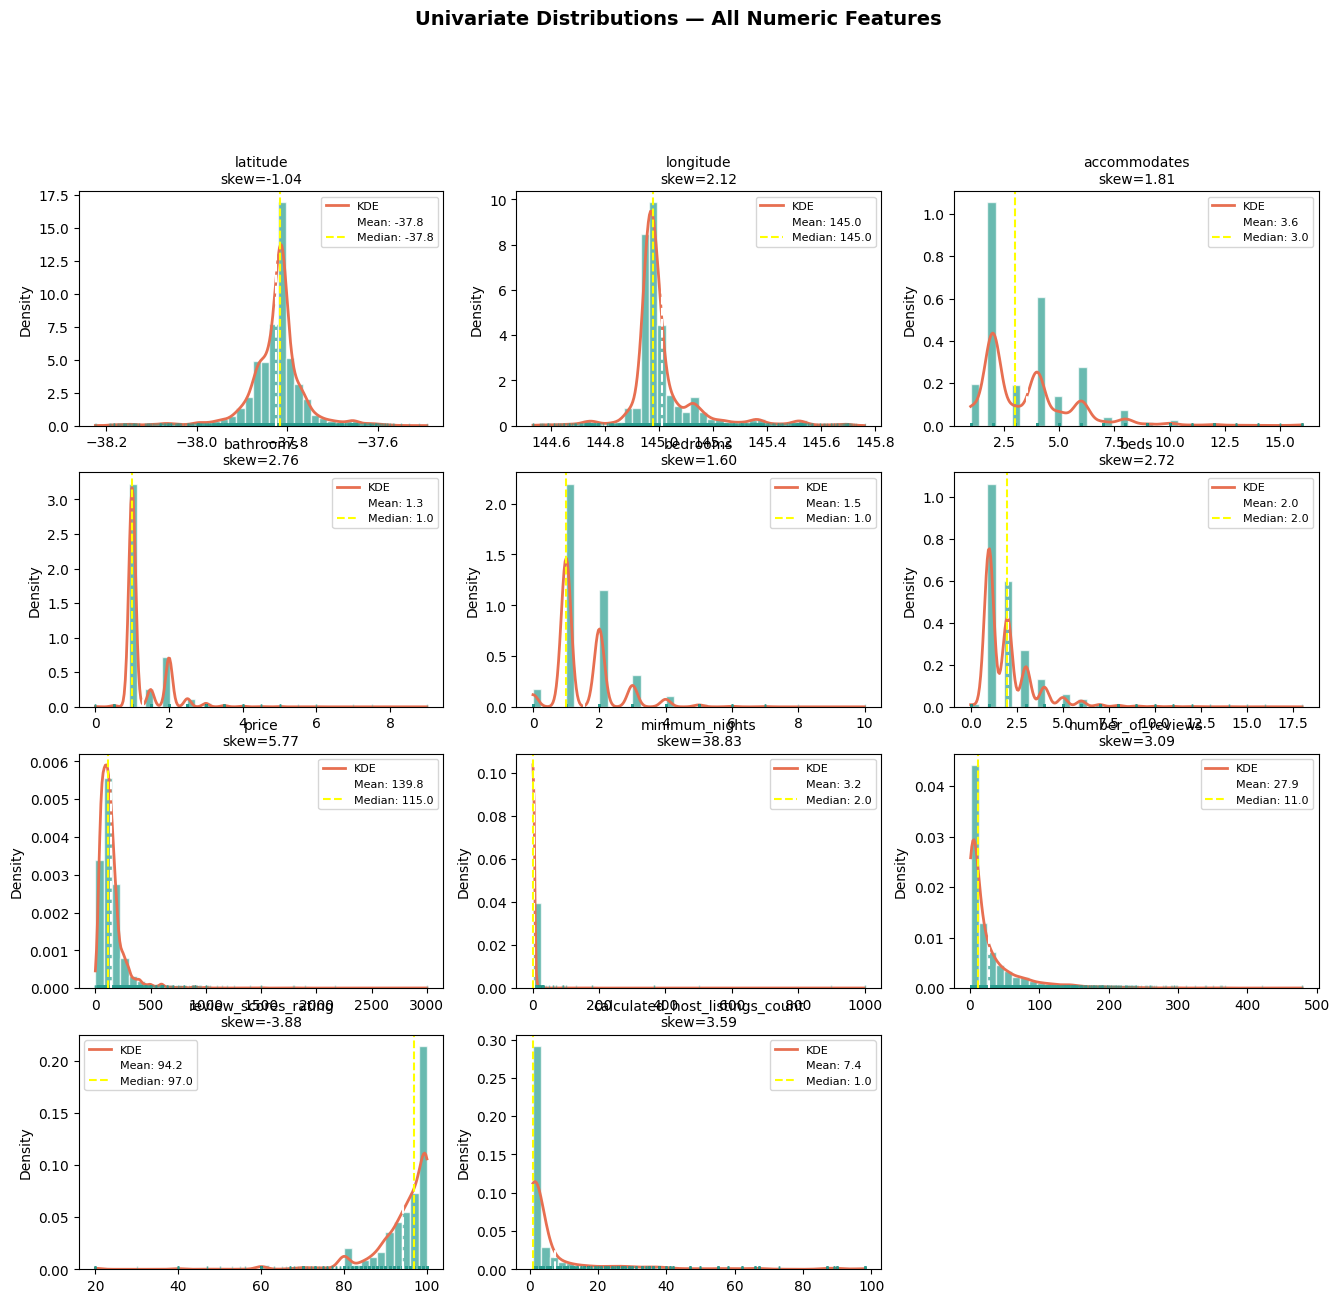

In [ ]:
# Distribution plots for all numeric features
# Using a histogram + KDE overlay + a rug plot for density at the base
TEAL = '#2a9d8f'
CORAL = '#e76f51'
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = train[col].dropna()
    
    # Histogram
    ax.hist(data, bins=40, color=TEAL, alpha=0.7, edgecolor='white', density=True)
    # density = true converts count to density so that we can overlay KDE on the same plot.
    
    # KDE overlay
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=CORAL, lw=2, label='KDE')
    
    # Rug plot
    ax.plot(data, np.zeros_like(data), '|', color=TEAL, alpha=0.3, markersize=5)
    
    # Mean and median lines
    ax.axvline(data.mean(), color='white', linestyle='--', lw=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='yellow', linestyle='--', lw=1.5, label=f'Median: {data.median():.1f}')
    # Mean is effected by outliers while median is not, so if mean shifts too left or too right, which means outliers exist in the data and we can also check the skewness of the data by looking aat the mean and median values, if they are close toeach other then the data us more likely to be symmetric and if they are far from eachother then the data is skewed.
    
    # Annotate skew
    skew_val = data.skew()
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Univariate Distributions — All Numeric Features',
    fontsize=14, fontweight='bold', y=1.01
)

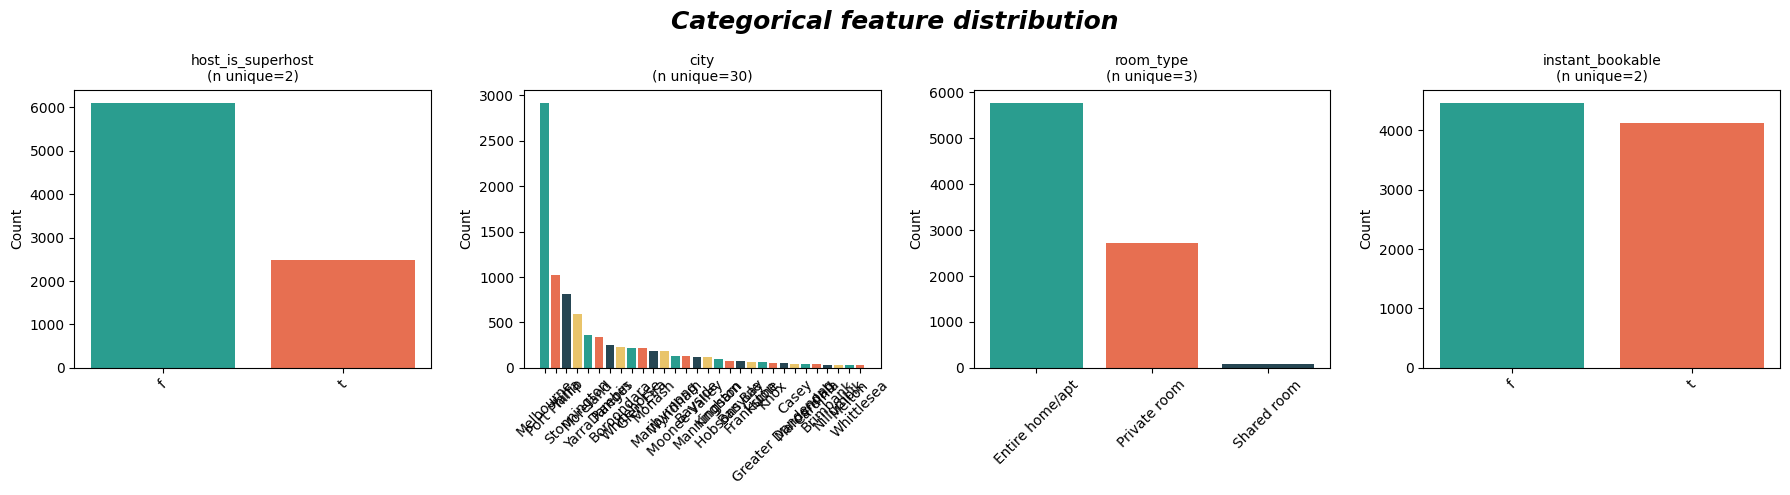

In [49]:
# Let's just do a simple bar chart for categorical features, it just shows the count of each value in a particular categorical feature 
colors = [TEAL, CORAL, '#264653', '#e9c46a']
fig,axes =plt.subplots(1,len(cat_cols),figsize=(18,5))
for i, col in enumerate(cat_cols):
  val_counts=train[col].value_counts()
  # counting the frequency of each value in a the categorical column
  axes[i].bar(val_counts.index,val_counts.values,color=colors[:len(val_counts)])
  axes[i].set_title(f'{col}\n(n unique={train[col].nunique()})',fontsize=10)
  axes[i].set_ylabel('Count')
  axes[i].tick_params(axis='x',rotation=45)

plt.suptitle('Categorical feature distribution',fontsize=18,fontweight='bold',fontstyle='italic')
plt.tight_layout()
plt.show()


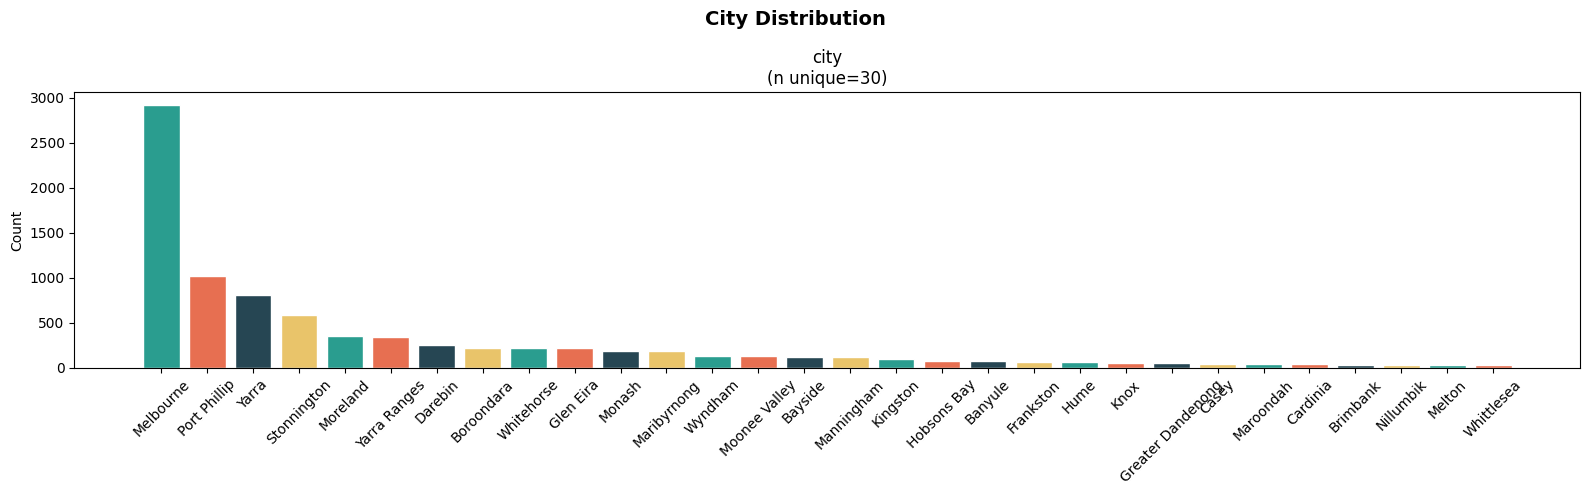

In [52]:
# seperate plot for city column 
fig, ax = plt.subplots(figsize=(16, 5))

val_counts = train['city'].value_counts()
ax.bar(val_counts.index, val_counts.values, color=colors[:len(val_counts)], edgecolor='white')
ax.set_title('city\n(n unique=30)', fontsize=12)
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('City Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()